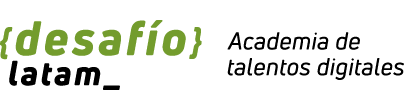

# <center><font color="green">Regresión (parte I)</font></center>

## <font color="green">Matriz de correlaciones</font>

Python nos permite determinar fácilmente las correlaciones entre cada par de variables contenidas en un dataset. En nuestro caso, utilizaremos los datos correspondientes a la base de datos de los pingüinos que vimos en la sesión anterior.


In [1]:
#cargamos las bibliotecas y la data
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import plotly.express as px
from matplotlib.colors import ListedColormap
from scipy import stats #modelos
from scipy.stats import norm, skew
from sklearn import preprocessing

# Cargar el conjunto de datos de pingüinos de seaborn
penguins = sns.load_dataset("penguins")

# Filtrar los datos sin valores faltantes
data = penguins.dropna()


In [2]:
data

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,Female
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


In [3]:
data.loc[:,'bill_length_mm':'body_mass_g']

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,39.1,18.7,181.0,3750.0
1,39.5,17.4,186.0,3800.0
2,40.3,18.0,195.0,3250.0
4,36.7,19.3,193.0,3450.0
5,39.3,20.6,190.0,3650.0
...,...,...,...,...
338,47.2,13.7,214.0,4925.0
340,46.8,14.3,215.0,4850.0
341,50.4,15.7,222.0,5750.0
342,45.2,14.8,212.0,5200.0


In [4]:
data.loc[:,'bill_length_mm':'body_mass_g'].corr()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.000000,-0.228626,0.653096,0.589451
bill_depth_mm,-0.228626,1.000000,-0.577792,-0.472016
flipper_length_mm,0.653096,-0.577792,1.000000,0.872979
body_mass_g,0.589451,-0.472016,0.872979,1.000000


In [5]:
data['sex'].value_counts()

sex
Male      168
Female    165
Name: count, dtype: int64

In [6]:
data['sex_binario'] = np.where(data['sex']=='Male', 0, 1)

/var/folders/v4/7dd1ltfn517dxr1cpnssshx00000gn/T/ipykernel_26722/3210234795.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['sex_binario'] = np.where(data['sex']=='Male', 0, 1)


In [7]:
data.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,sex_binario
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male,0
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female,1
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female,1
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female,1
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male,0


In [8]:
df_corr = data.loc[:,['bill_length_mm','bill_depth_mm','flipper_length_mm','body_mass_g', 'sex_binario']]

In [9]:
df_corr.corr()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex_binario
bill_length_mm,1.000000,-0.228626,0.653096,0.589451,-0.344078
bill_depth_mm,-0.228626,1.000000,-0.577792,-0.472016,-0.372673
flipper_length_mm,0.653096,-0.577792,1.000000,0.872979,-0.255169
body_mass_g,0.589451,-0.472016,0.872979,1.000000,-0.424987
sex_binario,-0.344078,-0.372673,-0.255169,-0.424987,1.000000


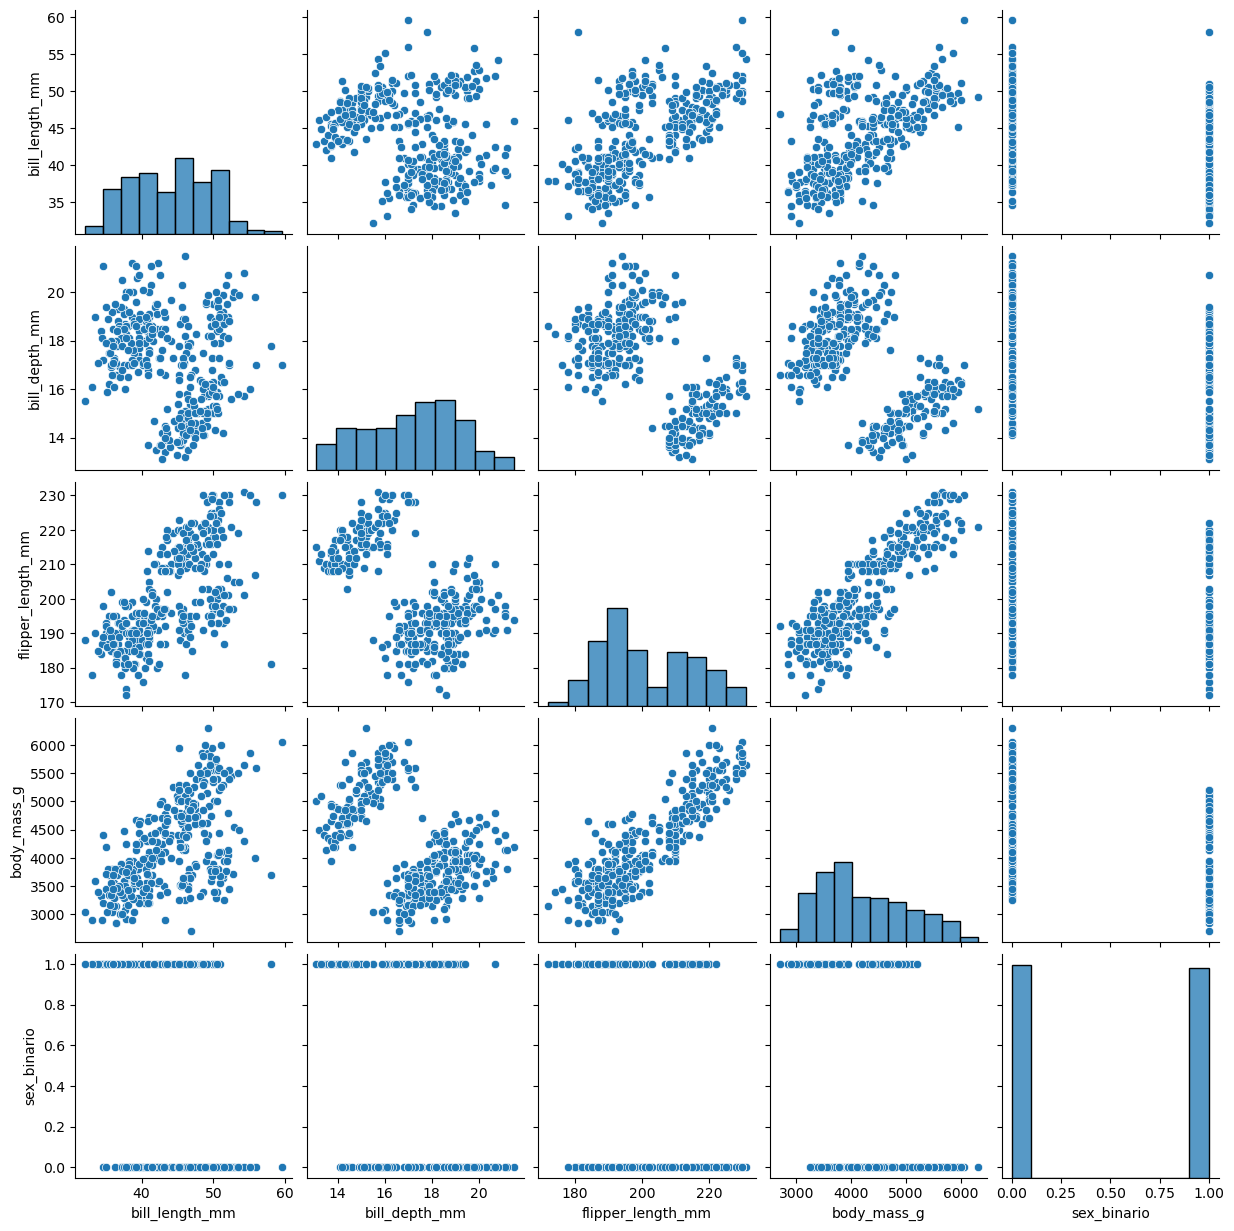

In [10]:
sns.pairplot(df_corr)

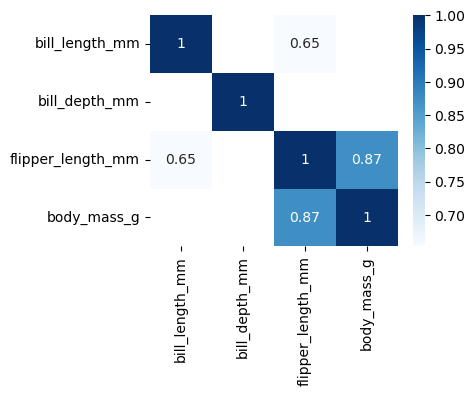

In [11]:
plt.figure(figsize=(4,3))
correlaciones = data.loc[:,'bill_length_mm':'body_mass_g'].corr()
corte = 0.6
sns.heatmap(correlaciones[(correlaciones > corte) | (correlaciones < (-1*corte))], annot=True, cmap='Blues')#plt.cm.PuBu)
'''
PuBu utiliza una gamna de colores en púrpura. Otras alternativas son:
- Viridis (cmap=plt.cm.viridis): es especialmente útil para representar datos
cuantitativos. Tiene una transición suave y uniforme de colores, lo que facilita
la interpretación de las relaciones.

- Coolwarm (cmap=plt.cm.coolwarm): Este es un mapa de color divergente que va
desde colores fríos (azules) a colores cálidos (rojos). Puede ser útil cuando
deseas resaltar diferencias positivas y negativas en tus datos.

- Greens (cmap=plt.cm.Greens): en tonos de verde

Reds (cmap=plt.cm.Reds): En tonos rojos

YlGnBu (cmap=plt.cm.YlGnBu): va desde amarillo hasta azul, pasando por tonos
verdes.

Pastel1 (cmap=plt.cm.Pastel1): Tonos pasteles

Accent (cmap=plt.cm.Accent): Tonos brillantes
'''
plt.show()

In [12]:
type(correlaciones)

pandas.core.frame.DataFrame

In [13]:
correlaciones[(correlaciones > 0.6) | (correlaciones < -0.6)]

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.000000,NaN,0.653096,NaN
bill_depth_mm,NaN,1.0,NaN,NaN
flipper_length_mm,0.653096,NaN,1.000000,0.872979
body_mass_g,NaN,NaN,0.872979,1.000000


In [ ]:
# Su ejecucion produce error al intentar usar columnas con texto data.corr()

In [ ]:
#data.corr()

In [14]:
correlaciones[(correlaciones > corte) | (correlaciones < (-1*corte))]

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.000000,NaN,0.653096,NaN
bill_depth_mm,NaN,1.0,NaN,NaN
flipper_length_mm,0.653096,NaN,1.000000,0.872979
body_mass_g,NaN,NaN,0.872979,1.000000


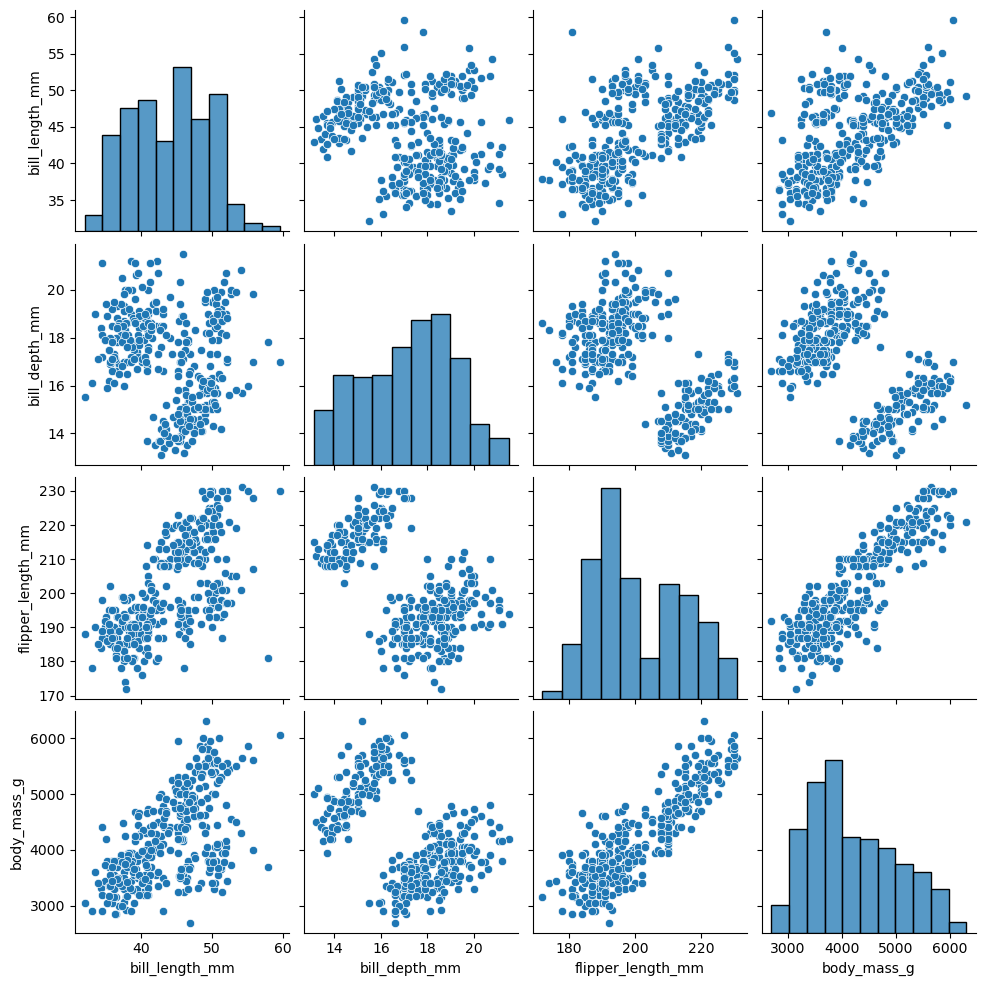

In [15]:
sns.pairplot(data.loc[:,'bill_length_mm':'body_mass_g'])

<center><strong>¡Podemos regresar a nuestra presentación!</strong></center>

## <font color="green">Regresión lineal simple</font>


Vamos a analizar, a partir de nuestra base de datos, las posibles relaciones entre las variables que presenta.

Vamos a examinar primero la posible relación entre Crearemos ahora un scatterplot, para visualizar la distribución de los pesos y largos de las aletas. Para ello, primero seleccionaremos esas columnas.

In [16]:
# Filtrar las columnas necesarias
data1 = data[["flipper_length_mm", "body_mass_g"]]
data1

,flipper_length_mm,body_mass_g
0,181.0,3750.0
1,186.0,3800.0
2,195.0,3250.0
4,193.0,3450.0
5,190.0,3650.0
...,...,...
338,214.0,4925.0
340,215.0,4850.0
341,222.0,5750.0
342,212.0,5200.0


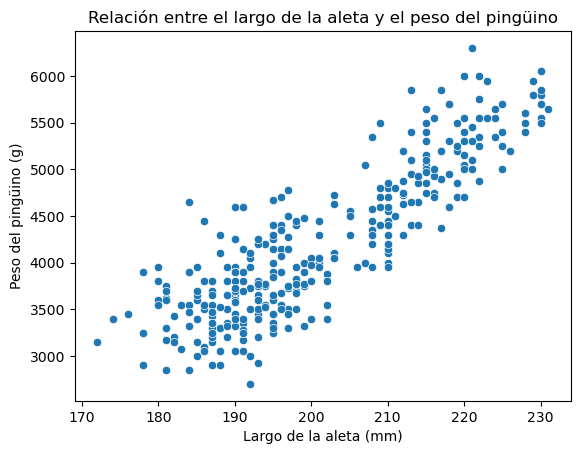

In [17]:
# Crear una gráfica de dispersión
sns.scatterplot(x="flipper_length_mm", y="body_mass_g", data=data1)
plt.title("Relación entre el largo de la aleta y el peso del pingüino")
plt.xlabel("Largo de la aleta (mm)")
plt.ylabel("Peso del pingüino (g)")
plt.show()

In [18]:
data1.corr()

,flipper_length_mm,body_mass_g
flipper_length_mm,1.000000,0.872979
body_mass_g,0.872979,1.000000


Intuitivamente, parece haber una correlación lineal positiva que verificaremos a continuación.

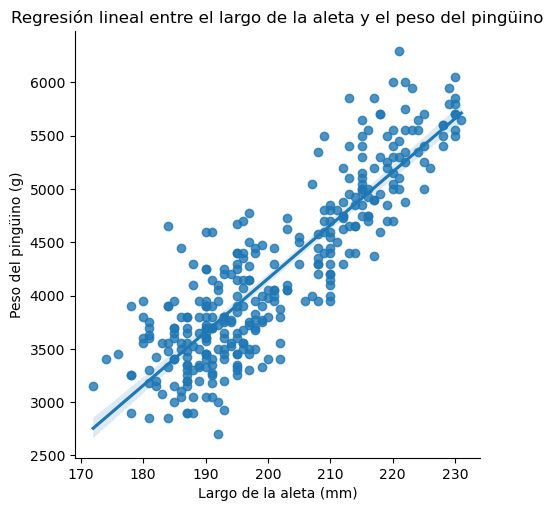

Pendiente: 50.15326594224109
Intercepto: -5872.092682842817
Error estándar: 1.5402309838246375
Coef. de correlación: 0.8729788985653607
Valor P del x respcto del y: 3.1328362509742264e-105


In [19]:
# Realizar la regresión lineal
sns.lmplot(x="flipper_length_mm", y="body_mass_g", data=data1)
plt.title("Regresión lineal entre el largo de la aleta y el peso del pingüino")
plt.xlabel("Largo de la aleta (mm)")
plt.ylabel("Peso del pingüino (g)")

# Calcular los valores de la regresión lineal. Ya veremos el significado de los parámetros
slope, intercept, r_value, p_value, std_err = stats.linregress(data["flipper_length_mm"], data["body_mass_g"])

# Mostrar el gráfico completo
plt.show()

print(f"Pendiente: {slope}")
print(f"Intercepto: {intercept}")
print(f"Error estándar: {std_err}")
print(f"Coef. de correlación: {r_value}")
print(f"Valor P del x respcto del y: {p_value}")

Podemos analizar ahora lo que ocurre con los residuos, lo que más adelante nos permitirá evaluar nuestro modelo.

Podríamos ver algo más aquí sobre regresión lineal múltiple, pero para ello necesitaremos algunas herramientas más.

## <font color = 'green'>Modelo de regresión lineal con Statsmodels</font>

Utilizaremos un módulo llamado statsmodels, que tiene documentación[ aquí](https://www.statsmodels.org/stable/gettingstarted.html).

El módulo statsmodels proporciona una amplia variedad de estadísticas de salida y parámetros de ajuste. Consulta la documentación completa de la regresión statsmodels [aquí](https://www.statsmodels.org/stable/regression.html).

Statsmodels contiene una función llamada .OLS() para realizar una regresión, buscando minimizar los cuadrados de los residuos. Un detalle importante es que se necesita agregar una columna de "1" a las variables predictoras, ya que esto (por motivos más largos de explicar) permite realizar un mejor ajuste del modelo.

In [20]:
X = data["flipper_length_mm"]
X

0      181.0
1      186.0
2      195.0
4      193.0
5      190.0
       ...  
338    214.0
340    215.0
341    222.0
342    212.0
343    213.0
Name: flipper_length_mm, Length: 333, dtype: float64

                      Results: Ordinary least squares
Model:                  OLS                Adj. R-squared:       0.761     
Dependent Variable:     body_mass_g        AIC:                  4926.1457 
Date:                   2025-10-16 20:30   BIC:                  4933.7620 
No. Observations:       333                Log-Likelihood:       -2461.1   
Df Model:               1                  F-statistic:          1060.     
Df Residuals:           331                Prob (F-statistic):   3.13e-105 
R-squared:              0.762              Scale:                1.5472e+05
---------------------------------------------------------------------------
                    Coef.    Std.Err.    t     P>|t|    [0.025     0.975]  
---------------------------------------------------------------------------
const             -5872.0927 310.2852 -18.9248 0.0000 -6482.4722 -5261.7131
flipper_length_mm    50.1533   1.5402  32.5622 0.0000    47.1234    53.1831
----------------------------------

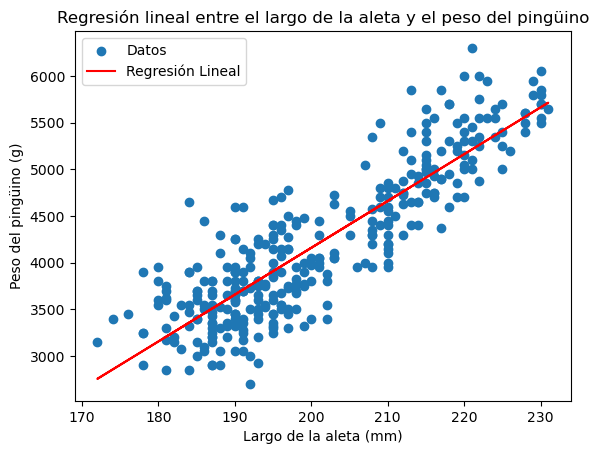

In [56]:
import statsmodels.api as sm

#Definir las variables predictoras (X) y la variable de respuesta (y)
X = data["flipper_length_mm"]
y = data["body_mass_g"]

# Agregar una constante al predictor (intercepto)
X = sm.add_constant(X)

# Crear el modelo de regresión lineal
model = sm.OLS(y, X)
model = model.fit() # entrenamos el modelo

# Obtener los resultados del modelo
results = model.summary2()

# Imprimir los resultados
print(results)

# Graficar la regresión lineal
plt.scatter(data["flipper_length_mm"], data["body_mass_g"], label="Datos")
plt.plot(data["flipper_length_mm"], model.predict(X), color='red', label="Regresión Lineal")  # predecimos los valores de y
plt.title("Regresión lineal entre el largo de la aleta y el peso del pingüino")
plt.xlabel("Largo de la aleta (mm)")
plt.ylabel("Peso del pingüino (g)")
plt.legend()
plt.show()



In [22]:
X_2 = data["flipper_length_mm"]
X_2

0      181.0
1      186.0
2      195.0
4      193.0
5      190.0
       ...  
338    214.0
340    215.0
341    222.0
342    212.0
343    213.0
Name: flipper_length_mm, Length: 333, dtype: float64

In [25]:
X_2 = sm.add_constant(X)
X_2

,const,flipper_length_mm
0,1.0,181.0
1,1.0,186.0
2,1.0,195.0
4,1.0,193.0
5,1.0,190.0
...,...,...
338,1.0,214.0
340,1.0,215.0
341,1.0,222.0
342,1.0,212.0


In [26]:
model2= sm.OLS(y, X_2).fit()

In [27]:
type(model2)

statsmodels.regression.linear_model.RegressionResultsWrapper

In [28]:
print(model2.summary2())

                      Results: Ordinary least squares
Model:                  OLS                Adj. R-squared:       0.761     
Dependent Variable:     body_mass_g        AIC:                  4926.1457 
Date:                   2025-10-16 20:15   BIC:                  4933.7620 
No. Observations:       333                Log-Likelihood:       -2461.1   
Df Model:               1                  F-statistic:          1060.     
Df Residuals:           331                Prob (F-statistic):   3.13e-105 
R-squared:              0.762              Scale:                1.5472e+05
---------------------------------------------------------------------------
                    Coef.    Std.Err.    t     P>|t|    [0.025     0.975]  
---------------------------------------------------------------------------
const             -5872.0927 310.2852 -18.9248 0.0000 -6482.4722 -5261.7131
flipper_length_mm    50.1533   1.5402  32.5622 0.0000    47.1234    53.1831
----------------------------------

In [29]:
model.predict(X)

0      3205.648453
1      3456.414782
2      3907.794176
4      3807.487644
5      3657.027846
          ...     
338    4860.706229
340    4910.859495
341    5261.932356
342    4760.399697
343    4810.552963
Length: 333, dtype: float64

In [30]:
y

0      3750.0
1      3800.0
2      3250.0
4      3450.0
5      3650.0
        ...  
338    4925.0
340    4850.0
341    5750.0
342    5200.0
343    5400.0
Name: body_mass_g, Length: 333, dtype: float64

In [31]:
from sklearn.metrics import median_absolute_error

In [32]:
y_hat= model.predict(X)

In [33]:
median_absolute_error(y, y_hat)

258.7137715476447

In [34]:
y.describe()

count     333.000000
mean     4207.057057
std       805.215802
min      2700.000000
25%      3550.000000
50%      4050.000000
75%      4775.000000
max      6300.000000
Name: body_mass_g, dtype: float64

In [35]:
y[0]

3750.0

In [36]:
y_hat[0]

3205.648452702823

In [37]:
data["flipper_length_mm"][0]

181.0

In [38]:
sm.add_constant(X)

,const,flipper_length_mm
0,1.0,181.0
1,1.0,186.0
2,1.0,195.0
4,1.0,193.0
5,1.0,190.0
...,...,...
338,1.0,214.0
340,1.0,215.0
341,1.0,222.0
342,1.0,212.0


In [39]:
181*50.1533 + -5872.0927

3205.6546000000008

In [40]:
model.predict(X)[0]

3205.648452702823

In [41]:
model.predict(X)

0      3205.648453
1      3456.414782
2      3907.794176
4      3807.487644
5      3657.027846
          ...     
338    4860.706229
340    4910.859495
341    5261.932356
342    4760.399697
343    4810.552963
Length: 333, dtype: float64

Podemos aplicar statsmodels para obtener un modelo de regresión para dos o más variables independientes. En nuestro caso, vamos a definir como variables independientes el largo de la aleta y el sexo; para esto último deberemos transformar esta variable categórica en numerica utilizando get.dummies

In [42]:
# Paso 1: Definir variables predictoras (X) y variable de respuesta (y)
X = data[['flipper_length_mm', 'sex']]  # Largo de la aleta y sexo como variables independientes
y = data['body_mass_g']  # Peso como variable dependiente

In [43]:
X['sex'].value_counts()

sex
Male      168
Female    165
Name: count, dtype: int64

In [44]:
X['sex']

0        Male
1      Female
2      Female
4      Female
5        Male
        ...  
338    Female
340    Female
341      Male
342    Female
343      Male
Name: sex, Length: 333, dtype: object

In [45]:
data

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,sex_binario
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male,0
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female,1
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female,1
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female,1
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male,0
...,...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,Female,1
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female,1
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male,0
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female,1


In [46]:
# Codificar la variable categórica 'sex' usando one-hot encoding
X_encoded = pd.get_dummies(X, columns=['sex'], prefix=['sex'], dtype='int64')

In [47]:
X_encoded

,flipper_length_mm,sex_Female,sex_Male
0,181.0,0,1
1,186.0,1,0
2,195.0,1,0
4,193.0,1,0
5,190.0,0,1
...,...,...,...
338,214.0,1,0
340,215.0,1,0
341,222.0,0,1
342,212.0,1,0


In [48]:
# Paso 2: Agregar una constante (intercepto) a las variables predictoras
X_encoded = sm.add_constant(X_encoded)

In [49]:
X_encoded

,const,flipper_length_mm,sex_Female,sex_Male
0,1.0,181.0,0,1
1,1.0,186.0,1,0
2,1.0,195.0,1,0
4,1.0,193.0,1,0
5,1.0,190.0,0,1
...,...,...,...,...
338,1.0,214.0,1,0
340,1.0,215.0,1,0
341,1.0,222.0,0,1
342,1.0,212.0,1,0


In [50]:

# Paso 3: Crear el modelo de regresión lineal
model = sm.OLS(y, X_encoded).fit()

In [51]:
# Paso 4: Obtener resultados del modelo
results = model.summary()
results

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            body_mass_g   R-squared:                       0.806
Model:                            OLS   Adj. R-squared:                  0.805
Method:                 Least Squares   F-statistic:                     684.8
Date:                Thu, 16 Oct 2025   Prob (F-statistic):          3.53e-118
Time:                        20:25:00   Log-Likelihood:                -2427.2
No. Observations:                 333   AIC:                             4860.
Df Residuals:                     330   BIC:                             4872.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const             -3490.9167    193.503    -18.041      0.000   -3871.572   -3110.262
flipper_length_mm    46.9822      1.441     32.598      0.000      44.147      49.817
sex_Female        -1919.3835     93.682    -20.488      0.000   -2103.673   -1735.094
sex_Male          -1571.5332    103.726    -15.151      0.000   -1775.581   -1367.485
==============================================================================
Omnibus:                        0.262   Durbin-Watson:                   1.701
Prob(Omnibus):                  0.877   Jarque-Bera (JB):                0.376
Skew:                           0.051   Prob(JB):                        0.829
Kurtosis:                       2.870   Cond. No.                     8.64e+17
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The smallest eigenvalue is 1.81e-29. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""

In [52]:
predictions = model.predict(X_encoded)

# Calcular el Error Cuadrático Medio (MSE)
mse = ((y - predictions) ** 2).mean()

# Calcular el Error Cuadrático Medio Explicado (EMSE)
emse = mse / ((y - y.mean()) ** 2).mean()


mae = (((y - predictions) ** 2)**1/2).mean()

mae = (abs(y - predictions)).mean()



# Obtener el valor R² del modelo
r2 = model.rsquared

print(results)
print()
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Error Mean Squared Explicado (EMSE): {emse:.2f}")
print(f"Coeficiente de Determinación (R²): {r2:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f} g")


                            OLS Regression Results                            
Dep. Variable:            body_mass_g   R-squared:                       0.806
Model:                            OLS   Adj. R-squared:                  0.805
Method:                 Least Squares   F-statistic:                     684.8
Date:                Thu, 16 Oct 2025   Prob (F-statistic):          3.53e-118
Time:                        20:25:00   Log-Likelihood:                -2427.2
No. Observations:                 333   AIC:                             4860.
Df Residuals:                     330   BIC:                             4872.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const             -3490.9167    193.50

In [53]:
abs(-2)

2

In [54]:
abs(y - predictions).mean()

283.2450078094367

In [55]:
model.summary2()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                      Results: Ordinary least squares
===========================================================================
Model:                  OLS                Adj. R-squared:       0.805     
Dependent Variable:     body_mass_g        AIC:                  4860.4843 
Date:                   2025-10-16 20:27   BIC:                  4871.9087 
No. Observations:       333                Log-Likelihood:       -2427.2   
Df Model:               2                  F-statistic:          684.8     
Df Residuals:           330                Prob (F-statistic):   3.53e-118 
R-squared:              0.806              Scale:                1.2665e+05
---------------------------------------------------------------------------
                    Coef.    Std.Err.    t     P>|t|    [0.025     0.975]  
---------------------------------------------------------------------------
const             -3490.9167 193.5030 -18.0406 0.0000 -3871.5718 -3110.2617
flipper_length_mm    46.9822   1.4413  32.5981 0.0000    44.1470    49.8174
sex_Female        -1919.3835  93.6819 -20.4883 0.0000 -2103.6726 -1735.0944
sex_Male          -1571.5332 103.7262 -15.1508 0.0000 -1775.5813 -1367.4852
---------------------------------------------------------------------------
Omnibus:             0.262       Durbin-Watson:          1.701             
Prob(Omnibus):       0.877       Jarque-Bera (JB):       0.376             
Skew:                0.051       Prob(JB):               0.829             
Kurtosis:            2.870       Condition No.:          863792565675378816
===========================================================================
Notes:
[1] Standard Errors assume that the covariance matrix of the errors is
correctly specified.
[2] The smallest eigenvalue is 1.81e-29. This might indicate that
there are strong multicollinearity problems or that the design
matrix is singular.
"""

¿Cómo podemos interpretar los resultados que nos entrega statsmodels?



<center><strong>¡Ahora podemos regresar a nuestra presentación!<center><strong>




## <font color = 'green'>Analizando el modelo</font>

Construiremos ahora un modelo para comparar los largos de las aletas y los pesos, pero separando entre pingüinos machos y hembras, parab luego analizar el modelo conjunto.

In [57]:
# Eliminar filas con valores faltantes
data_cleaned = data.dropna(subset=['body_mass_g', 'flipper_length_mm'])

# Filtrar los datos por género (macho y hembra)
pinguinos_macho = data_cleaned[data_cleaned['sex'] == 'Male']
pinguinos_hembra = data_cleaned[data_cleaned['sex'] == 'Female']

# Crear modelos de regresión lineal para cada género y para ambos juntos
model_macho = sm.OLS(pinguinos_macho['flipper_length_mm'], sm.add_constant(pinguinos_macho['body_mass_g'])).fit()
model_hembra = sm.OLS(pinguinos_hembra['flipper_length_mm'], sm.add_constant(pinguinos_hembra['body_mass_g'])).fit()
model_ambos = sm.OLS(data_cleaned['flipper_length_mm'], sm.add_constant(data_cleaned['body_mass_g'])).fit()

# Obtener las predicciones de cada modelo
predictions_macho = model_macho.predict()
predictions_hembra = model_hembra.predict()
predictions_ambos = model_ambos.predict()

# Calcular el Error Cuadrático Medio (MSE) para cada modelo
mse_macho = ((pinguinos_macho['flipper_length_mm'] - predictions_macho) ** 2).mean()
mse_hembra = ((pinguinos_hembra['flipper_length_mm'] - predictions_hembra) ** 2).mean()
mse_ambos = ((data_cleaned['flipper_length_mm'] - predictions_ambos) ** 2).mean()

# Calcular el Error Cuadrático Medio Explicado (EMSE) para cada modelo
emse_macho = mse_macho / ((pinguinos_macho['flipper_length_mm'] - pinguinos_macho['flipper_length_mm'].mean()) ** 2).mean()
emse_hembra = mse_hembra / ((pinguinos_hembra['flipper_length_mm'] - pinguinos_hembra['flipper_length_mm'].mean()) ** 2).mean()
emse_ambos = mse_ambos / ((data_cleaned['flipper_length_mm'] - data_cleaned['flipper_length_mm'].mean()) ** 2).mean()

# Calcular el Coeficiente de Determinación (R²) para cada modelo
r2_macho = model_macho.rsquared
r2_hembra = model_hembra.rsquared
r2_ambos = model_ambos.rsquared

# Calcular el Error Absoluto Medio (MAE) para cada modelo
mae_macho = (abs(pinguinos_macho['flipper_length_mm'] - predictions_macho)).mean()
mae_hembra = (abs(pinguinos_hembra['flipper_length_mm'] - predictions_hembra)).mean()
mae_ambos = (abs(data_cleaned['flipper_length_mm'] - predictions_ambos)).mean()


# Mostrar los resultados
print("Modelo para pingüinos macho:")
print(f"R²: {r2_macho:.2f}, MSE: {mse_macho:.2f}, EMSE: {emse_macho:.2f}, MAE: {mae_macho:.2f}")

print("\nModelo para pingüinos hembra:")
print(f"R²: {r2_hembra:.2f}, MSE: {mse_hembra:.2f}, EMSE: {emse_hembra:.2f}, MAE: {mae_hembra:.2f}")

print("\nModelo para ambos géneros juntos:")
print(f"R²: {round(r2_ambos,2)}, MSE: {mse_ambos:.2f}, EMSE: {emse_ambos:.2f}, MAE: {mae_ambos:.2f}")


Modelo para pingüinos macho:
R²: 0.75, MSE: 52.79, EMSE: 0.25, MAE: 6.04

Modelo para pingüinos hembra:
R²: 0.78, MSE: 33.72, EMSE: 0.22, MAE: 4.59

Modelo para ambos géneros juntos:
R²: 0.76, MSE: 46.59, EMSE: 0.24, MAE: 5.56


Analizando las mpetricas obtenidas tenemos que:

* El Coeficiente de Determinación (R²) indica la proporción de la variabilidad total en la variable dependiente que es explicada por el modelo. Cuanto más cercano a 1 sea el R², mejor es el ajuste del modelo a los datos. En este sentido, podemos ver que los modelos son similares en cuanto a nivel de ajuste.

*  El Error Cuadrático Medio (MSE) mide la magnitud promedio de los errores cuadrados entre las predicciones del modelo y los valores reales. Un MSE más bajo indica que el modelo tiene errores más pequeños y, por lo tanto, es mejor en términos de precisión. En este sentido, el modelo para las pingüinos hembra es notoriamente más preciso que los otros dos.

* El Error Cuadrático Medio Explicado (EMSE) es una variante del MSE que normaliza el error al dividirlo por la varianza de la variable dependiente. Permite comparar modelos en términos de la capacidad del modelo para explicar la variabilidad en los datos en relación con la varianza natural de los datos.
Un EMSE más bajo indica que el modelo es mejor para explicar la variabilidad en los datos. En este sentido, el modelo para las hembras es levemente mejor que los demás.

* El Error Absoluto Medio (MAE) mide la magnitud promedio de los errores absolutos entre las predicciones del modelo y los valores reales.
Es menos sensible a valores atípicos que el MSE, ya que no eleva los errores al cuadrado. Un modelo con un MAE más bajo se considera mejor en términos de precisión.

Podemos graficar para observar las relaciones.



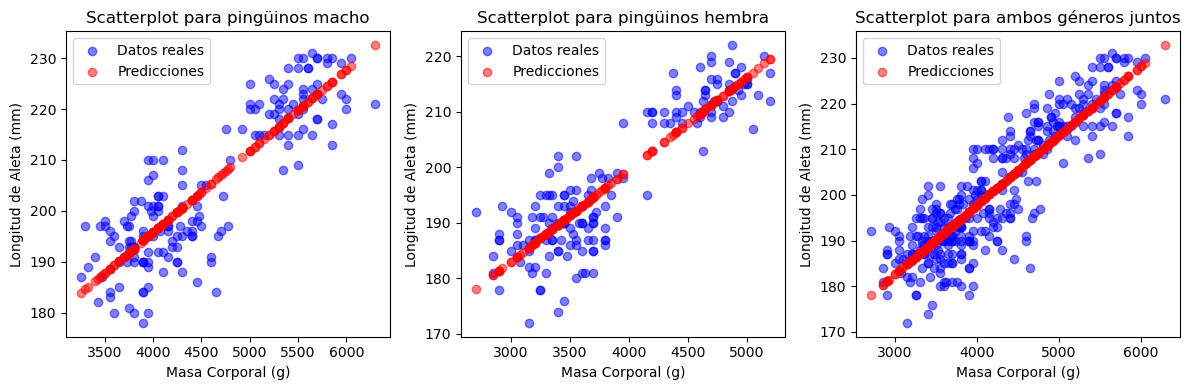

In [58]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.scatter(pinguinos_macho['body_mass_g'], pinguinos_macho['flipper_length_mm'], label='Datos reales', color='blue', alpha=0.5)
plt.scatter(pinguinos_macho['body_mass_g'], predictions_macho, label='Predicciones', color='red', alpha=0.5)
plt.xlabel('Masa Corporal (g)')
plt.ylabel('Longitud de Aleta (mm)')
plt.title('Scatterplot para pingüinos macho')
plt.legend()

# Scatterplot para los pingüinos hembra
plt.subplot(1, 3, 2)
plt.scatter(pinguinos_hembra['body_mass_g'], pinguinos_hembra['flipper_length_mm'], label='Datos reales', color='blue', alpha=0.5)
plt.scatter(pinguinos_hembra['body_mass_g'], predictions_hembra, label='Predicciones', color='red', alpha=0.5)
plt.xlabel('Masa Corporal (g)')
plt.ylabel('Longitud de Aleta (mm)')
plt.title('Scatterplot para pingüinos hembra')
plt.legend()

# Scatterplot para ambos géneros juntos
plt.subplot(1, 3, 3)
plt.scatter(data_cleaned['body_mass_g'], data_cleaned['flipper_length_mm'], label='Datos reales', color='blue', alpha=0.5)
plt.scatter(data_cleaned['body_mass_g'], predictions_ambos, label='Predicciones', color='red', alpha=0.5)
plt.xlabel('Masa Corporal (g)')
plt.ylabel('Longitud de Aleta (mm)')
plt.title('Scatterplot para ambos géneros juntos')
plt.legend()

# Mostrar los scatterplots
plt.tight_layout()
plt.show()

## DESAFIO

In [61]:
import pandas as pd
from sklearn.metrics import median_absolute_error, mean_squared_error
import statsmodels.api as sm
import numpy as np
import seaborn as sns

In [62]:
df = pd.read_csv("Fish.csv")

In [63]:
df.head()

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340


In [64]:
df.shape

(159, 7)

In [65]:
df['Volumen']= np.pi*df['Height']*(df['Width']/2)**2

In [66]:
df.head()

,Species,Weight,Length1,Length2,Length3,Height,Width,Volumen
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200,146.215854
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056,181.707071
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961,214.391723
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555,198.477454
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340,257.609344


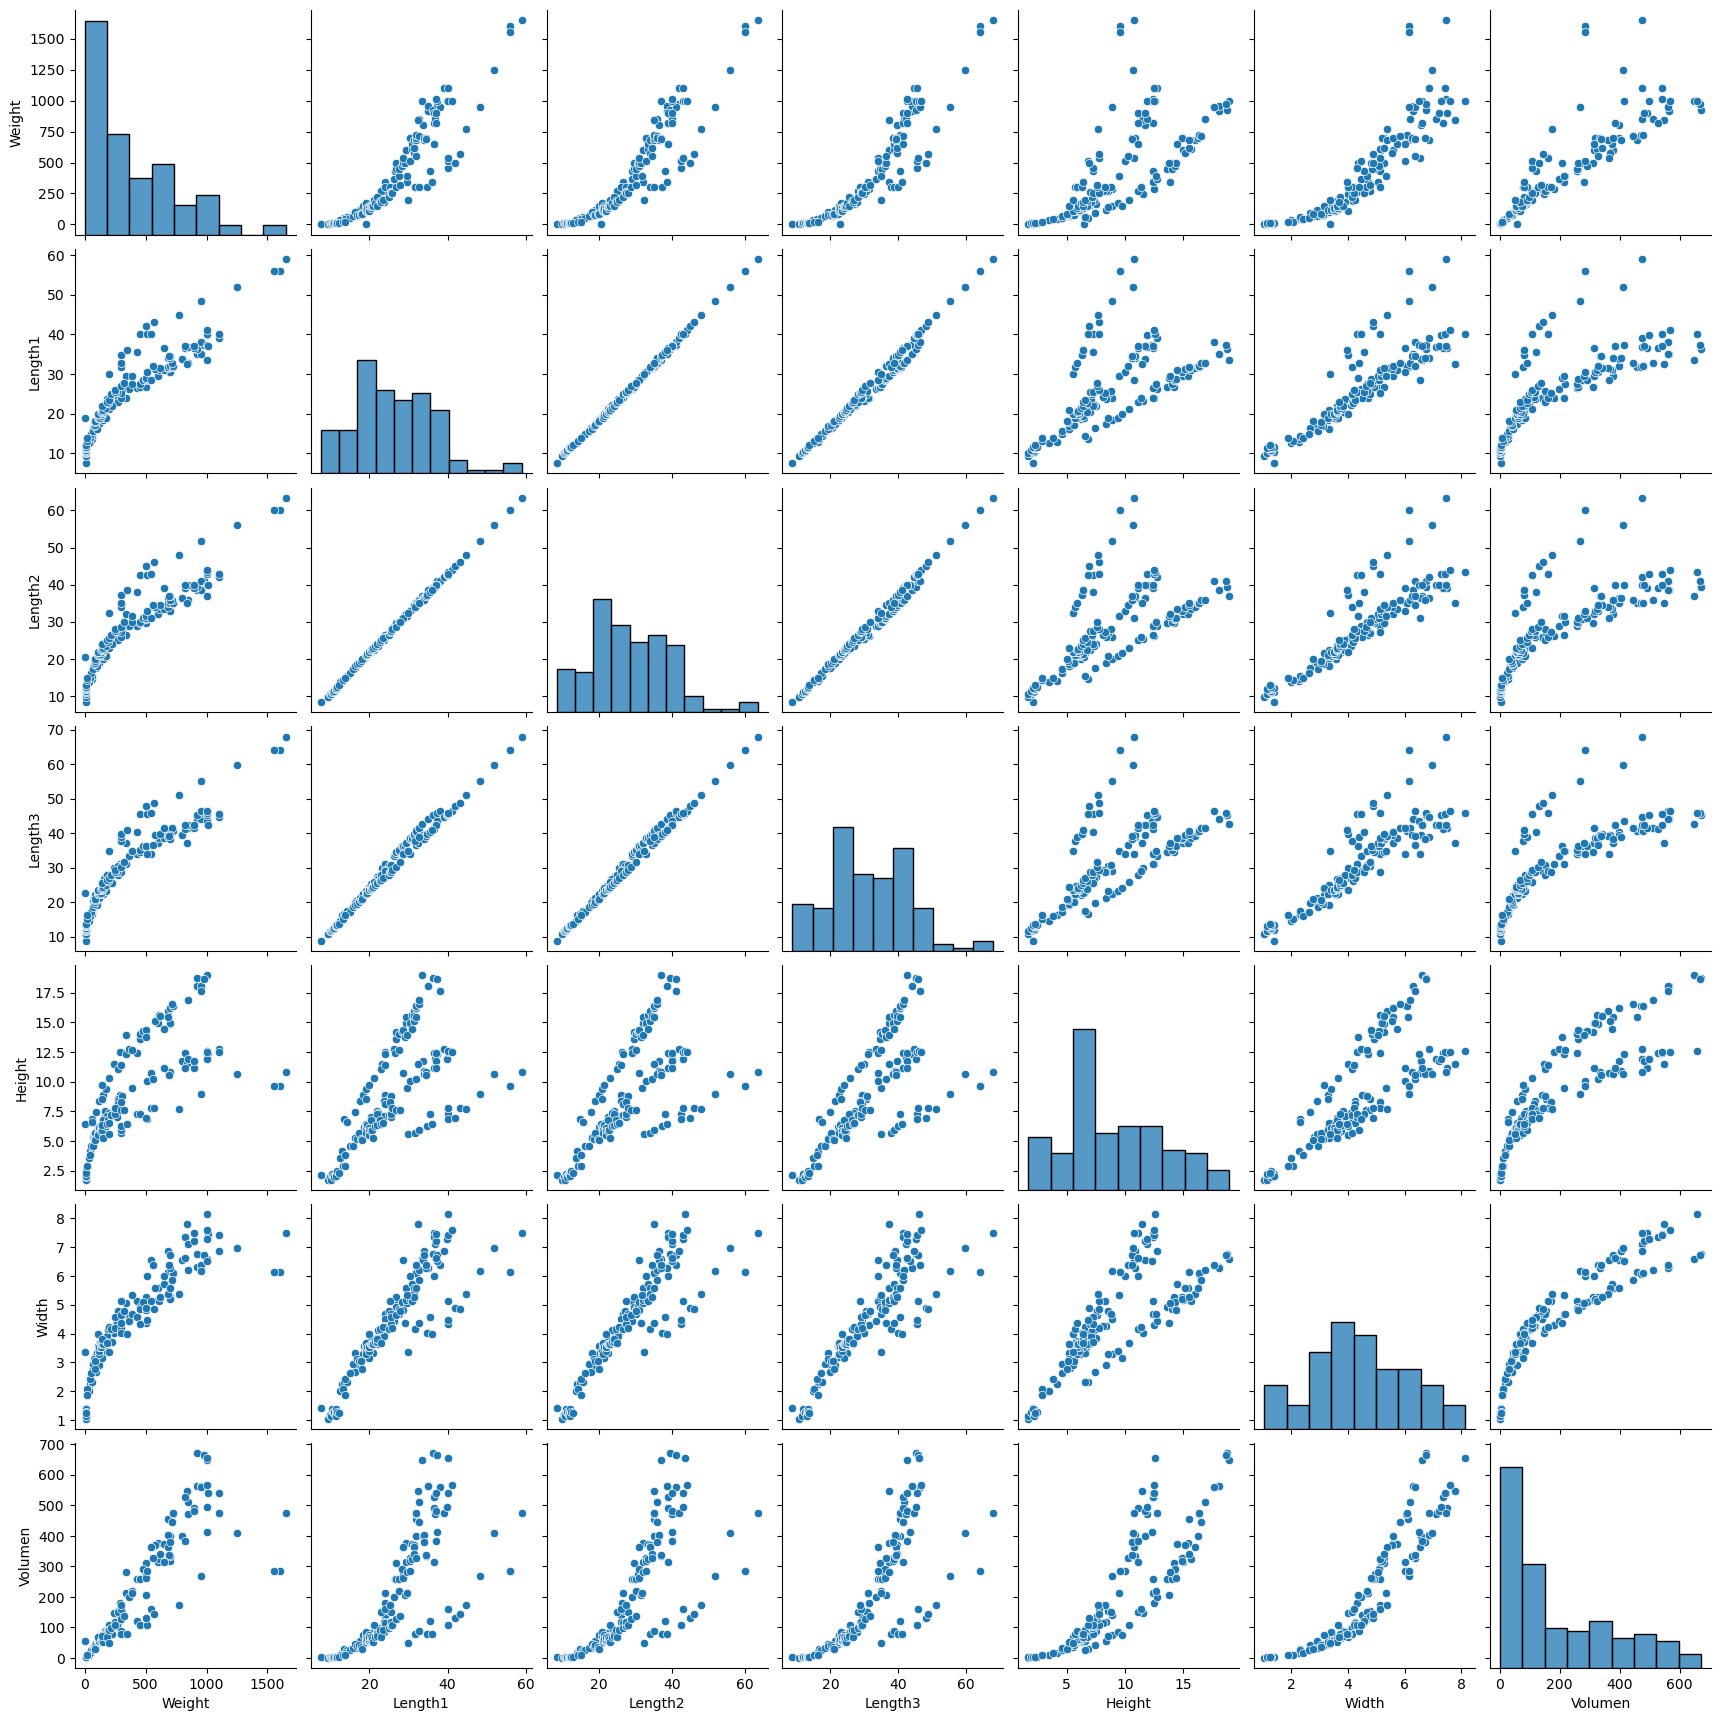

In [67]:
sns.pairplot(df.drop(columns=['Species']))

In [68]:
df.drop(columns=['Species']).corr()

,Weight,Length1,Length2,Length3,Height,Width,Volumen
Weight,1.000000,0.915712,0.918618,0.923044,0.724345,0.886507,0.881981
Length1,0.915712,1.000000,0.999517,0.992031,0.625378,0.867050,0.732409
Length2,0.918618,0.999517,1.000000,0.994103,0.640441,0.873547,0.741313
Length3,0.923044,0.992031,0.994103,1.000000,0.703409,0.878520,0.767774
Height,0.724345,0.625378,0.640441,0.703409,1.000000,0.792881,0.868256
Width,0.886507,0.867050,0.873547,0.878520,0.792881,1.000000,0.905626
Volumen,0.881981,0.732409,0.741313,0.767774,0.868256,0.905626,1.000000


<Axes: >

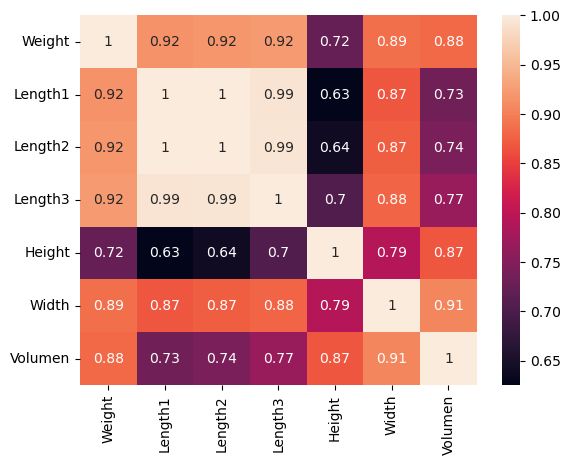

In [69]:
sns.heatmap(df.drop(columns=['Species']).corr(), annot=True)

                 Results: Ordinary least squares
Model:              OLS              Adj. R-squared:     0.776    
Dependent Variable: Weight           AIC:                2084.9801
Date:               2025-10-16 20:54 BIC:                2091.1180
No. Observations:   159              Log-Likelihood:     -1040.5  
Df Model:           1                F-statistic:        549.9    
Df Residuals:       157              Prob (F-statistic): 3.65e-53 
R-squared:          0.778            Scale:              28644.   
--------------------------------------------------------------------
            Coef.    Std.Err.      t      P>|t|     [0.025    0.975]
--------------------------------------------------------------------
const      58.7401    19.7453    2.9749   0.0034   19.7394   97.7407
Volumen     1.7396     0.0742   23.4491   0.0000    1.5931    1.8861
------------------------------------------------------------------
Omnibus:              156.660      Durbin-Watson:         0.435   
Pro

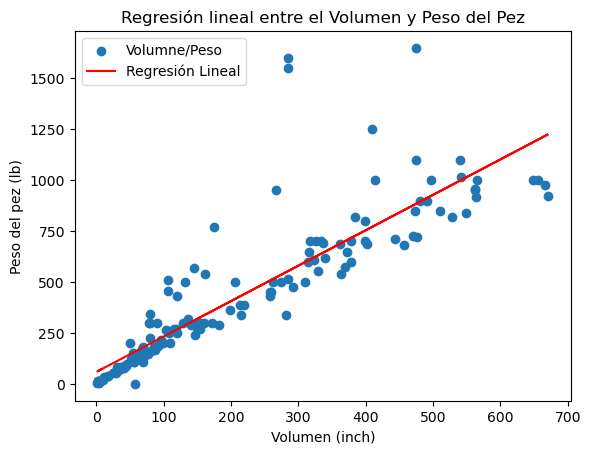

In [71]:
#Definir las variables predictoras (X) y la variable de respuesta (y)
X = df['Volumen']
y = df['Weight']

# Agregar una constante al predictor (intercepto)
X = sm.add_constant(X)

# Crear el modelo de regresión lineal
model = sm.OLS(y, X)
model = model.fit() # entrenamos el modelo

# Obtener los resultados del modelo
results = model.summary2()

# Imprimir los resultados
print(results)
print(f'MAE ==> {median_absolute_error(y, model.predict(X))}')

# Graficar la regresión lineal
plt.scatter(df["Volumen"], df["Weight"], label="Volumne/Peso")
plt.plot(df["Volumen"], model.predict(X), color='red', label="Regresión Lineal")  # predecimos los valores de y
plt.title("Regresión lineal entre el Volumen y Peso del Pez")
plt.xlabel("Volumen (inch)")
plt.ylabel("Peso del pez (lb)")
plt.legend()
plt.show()


In [72]:
df.head()

,Species,Weight,Length1,Length2,Length3,Height,Width,Volumen
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200,146.215854
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056,181.707071
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961,214.391723
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555,198.477454
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340,257.609344


In [73]:
df['Species'].value_counts()

Species
Perch        56
Bream        35
Roach        20
Pike         17
Smelt        14
Parkki       11
Whitefish     6
Name: count, dtype: int64

In [74]:
df['Species'].unique()

array(['Bream', 'Roach', 'Whitefish', 'Parkki', 'Perch', 'Pike', 'Smelt'],
      dtype=object)

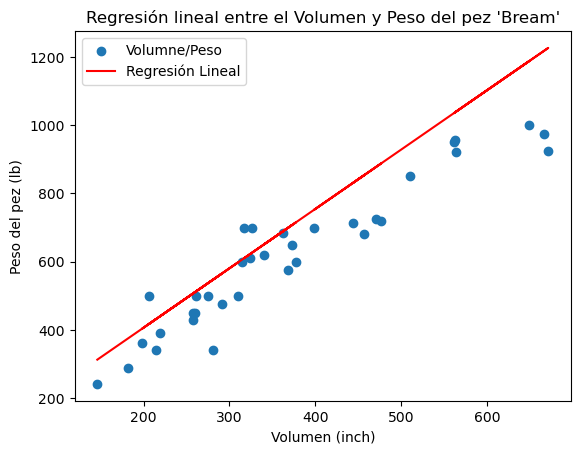

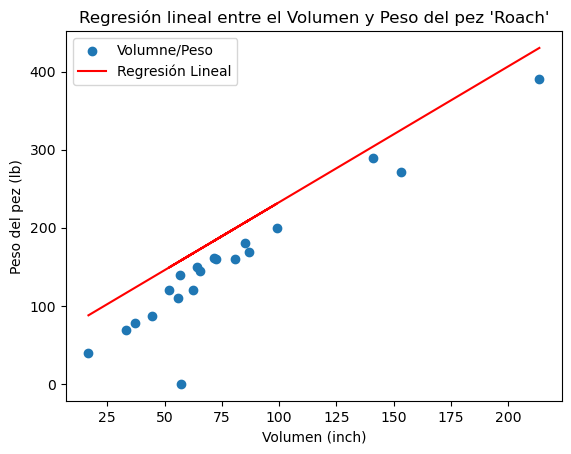

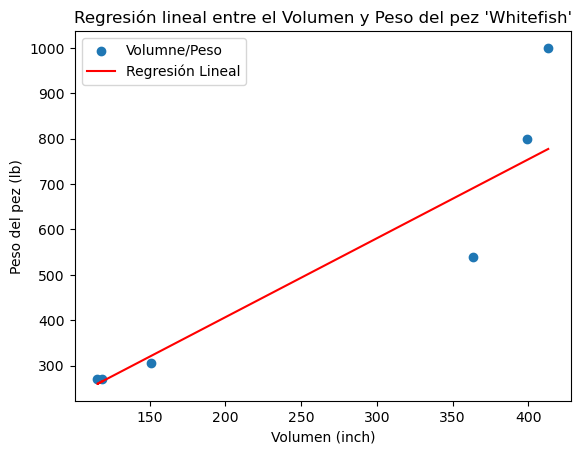

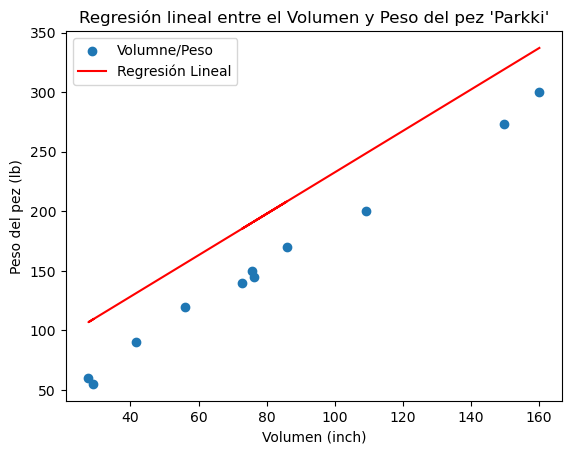

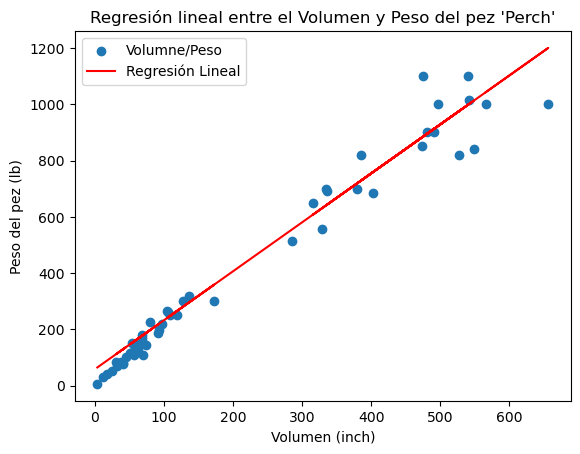

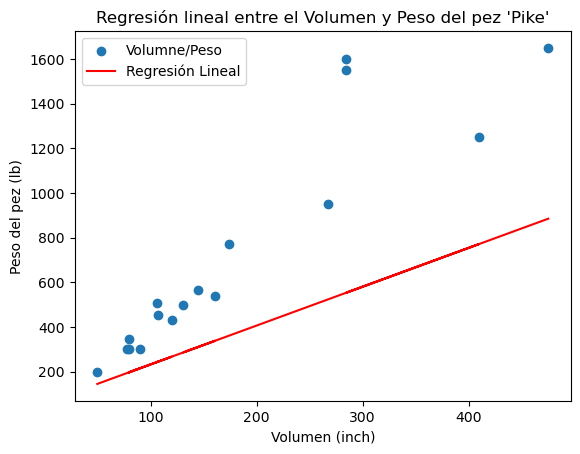

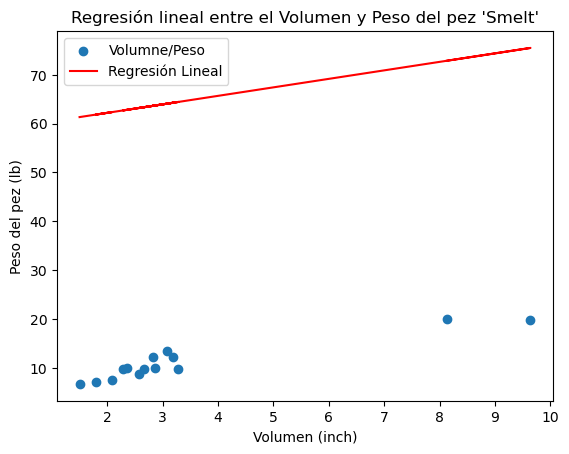

In [79]:
metricas = {}
for tipo in df['Species'].unique():
    y_de_la_especie = df[df['Species']==tipo]['Weight']
    X_de_la_especie = df[df['Species']==tipo]['Volumen']
    X_de_la_especie = sm.add_constant(X_de_la_especie)
    y_hat_de_la_especie = model.predict(X_de_la_especie)
    
    metricas[tipo] = {
        'MAE': median_absolute_error(y_de_la_especie, y_hat_de_la_especie),
        'R_cuadrado': model.rsquared,
        'especie': tipo
    }

    plt.scatter(df[df['Species']==tipo]['Volumen'], y_de_la_especie, label="Volumne/Peso")
    plt.plot(df[df['Species']==tipo]['Volumen'], y_hat_de_la_especie, color='red', label="Regresión Lineal")  # predecimos los valores de y
    plt.title("Regresión lineal entre el Volumen y Peso del pez '{tipo}'")
    plt.xlabel("Volumen (inch)")
    plt.ylabel("Peso del pez (lb)")
    plt.legend()
    plt.show()


In [80]:
metricas

{'Bream': {'MAE': 84.83691645209916,
  'R_cuadrado': 0.777891062387765,
  'especie': 'Bream'},
 'Roach': {'MAE': 39.67240340308915,
  'R_cuadrado': 0.777891062387765,
  'especie': 'Roach'},
 'Whitefish': {'MAE': 31.240012520570787,
  'R_cuadrado': 0.777891062387765,
  'especie': 'Whitefish'},
 'Parkki': {'MAE': 45.338027094341356,
  'R_cuadrado': 0.777891062387765,
  'especie': 'Parkki'},
 'Perch': {'MAE': 37.56879329534158,
  'R_cuadrado': 0.777891062387765,
  'especie': 'Perch'},
 'Pike': {'MAE': 213.3148201720706,
  'R_cuadrado': 0.777891062387765,
  'especie': 'Pike'},
 'Smelt': {'MAE': 53.654164487818214,
  'R_cuadrado': 0.777891062387765,
  'especie': 'Smelt'}}

In [82]:
df['Species'].value_counts('%')

Species
Perch        0.352201
Bream        0.220126
Roach        0.125786
Pike         0.106918
Smelt        0.088050
Parkki       0.069182
Whitefish    0.037736
Name: proportion, dtype: float64